# Task 5 — Which dimension of corruption moves with governing populism?

This notebook decomposes the composite V-Dem political-corruption index into executive,
public-sector, legislative, and judicial corruption. It asks whether the Task 3 contemporaneous
association and Task 4 temporal-direction conclusions conceal dimension-specific patterns.

**Pre-declared analysis.** The specifications, outcome orientation, multiplicity correction, and
interpretation rules are recorded in `specs/corruption_decomposition.md`. The reusable code lives in
`src/decomposition/`; this notebook presents and interprets those results without modifying the
completed Task 3/4 modules.

## 1. Design and outcome orientation

All model outcomes are oriented so that **higher means more corruption**:

| Dimension | Main regression variable | Transformation |
|---|---|---|
| Composite benchmark | `v2x_corr` | none |
| Executive | `v2x_execorr` | none |
| Public sector | `v2x_pubcorr` | none |
| Legislative | `v2lgcrrpt` | multiplied by −1 |
| Judicial | `v2jucorrdc` | multiplied by −1 |

The continuous latent estimates are used for legislative and judicial models. Their `_01` versions
have only five categories and are therefore retained for descriptive presentation, not used as the
primary fixed-effects outcomes.

Two estimands remain separate:

1. **Contemporaneous association:** same-year within-country co-movement using country and year FE.
2. **Temporal ordering:** two-lag lead-lag and Granger-style models in both directions.

Neither estimand is a causal effect. Granger-style significance means incremental temporal
predictability after conditioning on the dependent variable's own history.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import decomposition as D  # noqa: E402

PANEL = ROOT / "data/processed/panel_populism_corruption.parquet"
panel = pd.read_parquet(PANEL)
results = D.run_complete_analysis(panel)

print(
    f"Panel: {len(panel):,} country-years, {panel.country_id.nunique()} countries, "
    f"{panel.year.min()}–{panel.year.max()}"
)

Panel: 3,965 country-years, 96 countries, 1970–2019


## 2. Is there enough within-country information?

Fixed effects learn from changes inside a country, not from permanent differences between countries.
The table therefore reports missingness, within-country variance, persistence, and countries whose
outcome never changes. Very high autocorrelation means that annual directional effects will be hard
to identify and that own-outcome lags are essential.

In [2]:
diagnostic_columns = [
    "outcome",
    "n_obs",
    "n_missing",
    "n_unique_values",
    "within_variance_share",
    "lag1_autocorrelation",
    "countries_no_within_variation",
    "median_unique_values_per_country",
]
results["diagnostics"][diagnostic_columns].round(3)

,outcome,n_obs,n_missing,n_unique_values,within_variance_share,lag1_autocorrelation,countries_no_within_variation,median_unique_values_per_country
0,Composite,3965,0,738,0.125,0.993,2,15.5
1,Executive,3965,0,624,0.172,0.987,3,11.0
2,Public sector,3965,0,584,0.160,0.990,3,9.0
3,Legislative,3770,195,615,0.124,0.992,6,7.0
4,Judicial,3965,0,544,0.111,0.992,5,5.0


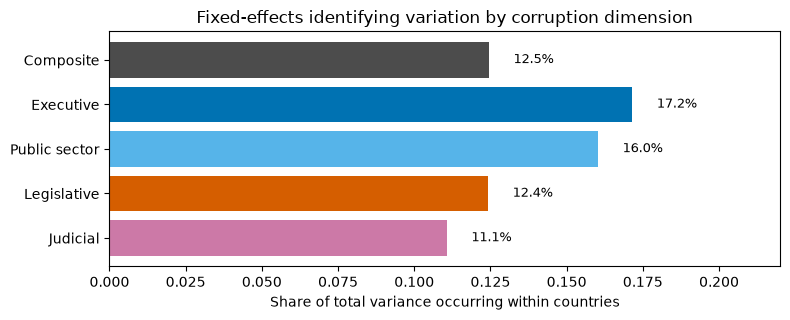

In [3]:
fig, ax = plt.subplots(figsize=(8, 3.3))
D.variation_diagnostics_plot(results["diagnostics"], ax)
fig.tight_layout()
plt.show()

All outcomes contain usable within-country variation, but only about 11–17% of their total variance
occurs within countries. Lag-1 autocorrelations are approximately 0.99. Legislative corruption has
195 missing rows and six countries with no within variation; judicial corruption has the smallest
within-variance share and five invariant countries. These constraints warrant cautious effect-size
and null-result interpretation.

## 3. Contemporaneous two-way fixed-effects decomposition

For each outcome, M1–M3 are estimated on one frozen sample. M3 controls for log GDP per capita and
electoral democracy. Country-clustered standard errors account for serial dependence. Benjamini–
Hochberg correction controls the FDR across the four subtype M3 tests; the composite is a benchmark,
not a fifth discovery test.

Because the raw scales differ, cross-dimension comparisons use a within-standardised coefficient:

`beta × within-SD(populism) / within-SD(outcome)`.

In [4]:
association = results["association"]
m3 = association[
    (association["model"] == "M3") & (association["sample_mode"] == "outcome_specific")
]
m3[
    [
        "outcome",
        "coefficient",
        "ci_low",
        "ci_high",
        "p_value",
        "fdr_q_value",
        "standardized_coefficient",
        "standardized_ci_low",
        "standardized_ci_high",
        "n_obs",
        "n_countries",
    ]
].round(4)

,outcome,coefficient,ci_low,ci_high,p_value,fdr_q_value,standardized_coefficient,standardized_ci_low,standardized_ci_high,n_obs,n_countries
2,Composite,-0.0638,-0.1234,-0.0042,0.0358,NaN,-0.0970,-0.1877,-0.0064,3940,95
5,Executive,0.0165,-0.0633,0.0964,0.6847,0.6847,0.0209,-0.0799,0.1217,3940,95
8,Public sector,-0.0734,-0.1489,0.0021,0.0567,0.1134,-0.0971,-0.1969,0.0028,3940,95
11,Legislative,-0.2431,-0.5818,0.0956,0.1594,0.2125,-0.0758,-0.1814,0.0298,3745,95
14,Judicial,-0.5395,-0.8843,-0.1948,0.0022,0.0087,-0.1735,-0.2843,-0.0626,3940,95


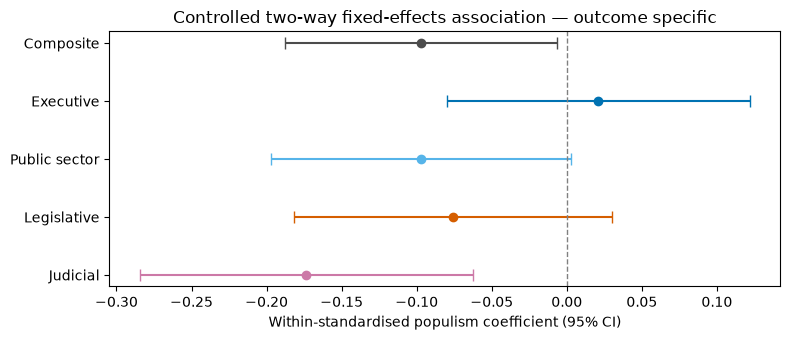

In [5]:
fig, ax = plt.subplots(figsize=(8, 3.5))
D.association_forest_plot(association, "outcome_specific", ax)
fig.tight_layout()
plt.show()

### Association result

- The composite reproduces Task 3: a small negative within-country coefficient (standardised
  β = −0.097, p = 0.036).
- Executive corruption is near zero (β = +0.021, q = 0.685).
- Public-sector and legislative corruption are negative but imprecise after FDR
  (β = −0.097/−0.076, q = 0.113/0.213).
- Judicial corruption has the clearest negative association (β = −0.173, p = 0.002,
  q = 0.009).

Thus, the negative composite association is not uniform. It is concentrated most clearly in the
judicial measure, while there is no positive executive-corruption association. This is a same-year
observational pattern, not evidence that populism improves judicial integrity.

## 4. Common-sample robustness

Legislative missingness can otherwise make dimension comparisons depend on different countries and
years. Every M3 model is therefore repeated on rows complete for all five outcomes and controls.

In [6]:
common_m3 = association[(association["model"] == "M3") & (association["sample_mode"] == "common")]
common_m3[
    [
        "outcome",
        "standardized_coefficient",
        "standardized_ci_low",
        "standardized_ci_high",
        "p_value",
        "fdr_q_value",
        "n_obs",
    ]
].round(4)

,outcome,standardized_coefficient,standardized_ci_low,standardized_ci_high,p_value,fdr_q_value,n_obs
17,Composite,-0.0903,-0.1880,0.0074,0.0700,NaN,3745
20,Executive,0.0266,-0.0764,0.1295,0.6130,0.6130,3745
23,Public sector,-0.0996,-0.2083,0.0090,0.0722,0.1444,3745
26,Legislative,-0.0758,-0.1814,0.0298,0.1594,0.2125,3745
29,Judicial,-0.1441,-0.2543,-0.0338,0.0104,0.0418,3745


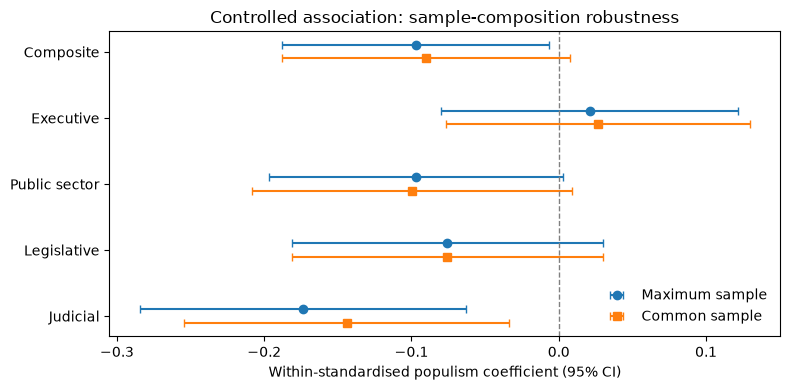

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.0))
D.association_sample_comparison_plot(association, ax)
fig.tight_layout()
plt.show()

The substantive ranking is stable. On the common sample, the judicial estimate remains negative
(β = −0.144) and survives FDR at q = 0.042. The composite becomes slightly less precise, while the
other subtype conclusions remain unchanged. The judicial result is therefore not an artefact of its
larger available sample.

### Association inference and measurement robustness

The M3 point estimate is re-evaluated using country clustering, country-and-year clustering,
Driscoll–Kraay errors, and a first-difference estimator. Legislative and judicial models are also
repeated with the five-level `_01` measures to check that orientation or latent scaling does not
create the sign.

In [8]:
association_robustness = results["association_robustness"]
association_robustness[association_robustness["outcome_key"] == "judicial"][
    [
        "outcome",
        "estimator",
        "coefficient",
        "standardized_coefficient",
        "p_value",
        "fdr_q_value",
        "n_obs",
    ]
].round(4)

,outcome,estimator,coefficient,standardized_coefficient,p_value,fdr_q_value,n_obs
16,Judicial,cluster_country,-0.5395,-0.1735,0.0022,0.0087,3940
17,Judicial,cluster_country_year,-0.5395,-0.1735,0.0021,0.0083,3940
18,Judicial,driscoll_kraay,-0.5395,-0.1735,0.0000,0.0000,3940
19,Judicial,first_difference,-0.1631,-0.0802,0.0335,0.1339,3845


In [9]:
results["measurement_robustness"][
    [
        "outcome",
        "measure",
        "coefficient",
        "standardized_coefficient",
        "p_value",
        "n_obs",
    ]
].round(4)

,outcome,measure,coefficient,standardized_coefficient,p_value,n_obs
0,Legislative,continuous_latent_primary,-0.2431,-0.0758,0.1594,3745
1,Legislative,five_level_ordinal_01,-0.0460,-0.0664,0.2572,3745
2,Judicial,continuous_latent_primary,-0.5395,-0.1735,0.0022,3940
3,Judicial,five_level_ordinal_01,-0.0817,-0.1365,0.0257,3940


The judicial coefficient is unchanged and FDR-significant under country, two-way, and
Driscoll–Kraay covariance estimators. First differences retain the negative sign and are nominally
significant (p = 0.033), but do not survive the four-outcome FDR correction (q = 0.134). The coarse
ordinal judicial measure also remains negative (standardised β = −0.137, p = 0.026). The judicial
sign is therefore robust to inference and measurement choices, while its confirmatory significance
is weaker under first differences.

## 5. Temporal ordering: lead-lag and Granger-style tests

The primary temporal model includes two lags of both the proposed cause and the dependent variable,
plus controls and two-way fixed effects. The joint Wald null is that both proposed-cause lags equal
zero. FDR is controlled across the eight subtype-by-direction tests.

In [10]:
direction_models = results["direction_models"]
primary_granger = direction_models[
    (direction_models["model"] == "granger")
    & (direction_models["sample_mode"] == "outcome_specific")
]
primary_granger[
    [
        "outcome",
        "direction",
        "joint_statistic",
        "joint_p_value",
        "fdr_q_value",
        "n_obs",
        "n_countries",
    ]
].round(4)

,outcome,direction,joint_statistic,joint_p_value,fdr_q_value,n_obs,n_countries
1,Composite,populism_to_corruption,0.7532,0.6862,NaN,3750,95
3,Composite,corruption_to_populism,2.8483,0.2407,NaN,3750,95
5,Executive,populism_to_corruption,1.4031,0.4958,0.6611,3750,95
7,Executive,corruption_to_populism,0.2792,0.8697,0.8697,3750,95
9,Public sector,populism_to_corruption,0.6178,0.7343,0.8392,3750,95
11,Public sector,corruption_to_populism,2.9683,0.2267,0.5023,3750,95
13,Legislative,populism_to_corruption,11.3148,0.0035,0.0279,3501,95
15,Legislative,corruption_to_populism,5.4930,0.0642,0.2566,3527,95
17,Judicial,populism_to_corruption,2.3035,0.3161,0.5057,3750,95
19,Judicial,corruption_to_populism,2.7634,0.2512,0.5023,3750,95


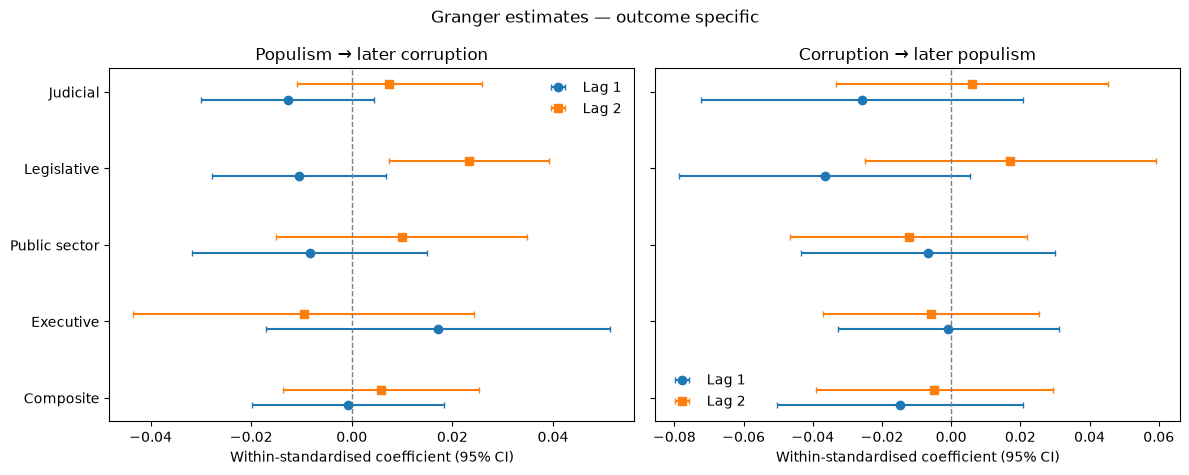

In [11]:
fig = D.direction_lag_plot(
    results["direction_terms"], model="granger", sample_mode="outcome_specific"
)
plt.show()

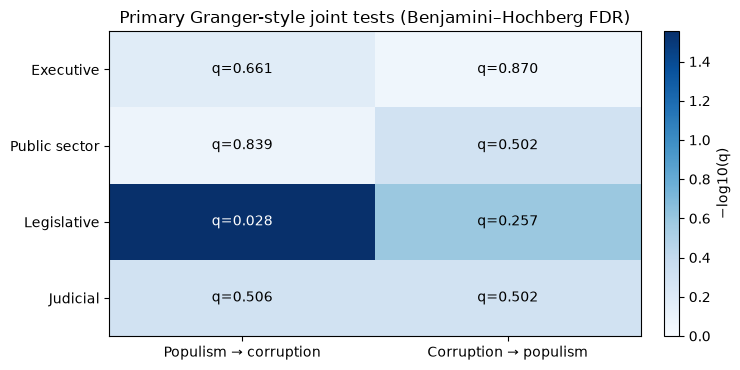

In [12]:
fig, ax = plt.subplots(figsize=(7.5, 3.8))
D.direction_fdr_heatmap(direction_models, "granger", "outcome_specific", ax)
fig.tight_layout()
plt.show()

### Temporal result

No robust temporal signal appears for executive, public-sector, or judicial corruption in either
direction. The only FDR-surviving subtype test is **populism → legislative corruption**
(joint p = 0.0035, q = 0.0279).

The legislative result is delayed and small:

- lag 1: raw coefficient −0.0328, p = 0.236;
- lag 2: raw coefficient +0.0733, p = 0.004, within-standardised coefficient +0.0234.

The positive lag-2 sign means more governing populism is followed by a small increase in measured
legislative corruption two years later, conditional on legislative corruption's own past. The
reverse legislative direction is not significant after FDR (p = 0.064, q = 0.257). The result is
identical on the common sample because legislative coverage determines the common directional rows.

## 6. Robustness and falsification checks

Three checks delimit how strongly the legislative signal can be interpreted:

1. placebo leads test for future proposed causes;
2. first differences, which focus on changes rather than persistent levels;
3. samples tied more closely to elections and observed government changes.

In [13]:
placebo = results["placebo"]
placebo[placebo["outcome_key"].isin(["legislative", "judicial"])][
    [
        "outcome",
        "direction",
        "joint_p_value",
        "fdr_q_value",
        "n_obs",
    ]
].round(4)

,outcome,direction,joint_p_value,fdr_q_value,n_obs
6,Legislative,populism_to_corruption,0.1013,0.2395,3388
7,Legislative,corruption_to_populism,0.0177,0.1167,3276
8,Judicial,populism_to_corruption,0.0292,0.1167,3560
9,Judicial,corruption_to_populism,0.1197,0.2395,3560


In [14]:
first_differences = results["first_differences"]
first_differences[first_differences["outcome_key"].isin(["legislative", "judicial"])][
    [
        "outcome",
        "direction",
        "coefficient",
        "standardized_coefficient",
        "p_value",
        "fdr_q_value",
        "n_obs",
    ]
].round(4)

,outcome,direction,coefficient,standardized_coefficient,p_value,fdr_q_value,n_obs
6,Legislative,populism_to_corruption,-0.0259,-0.0125,0.3738,0.7420,3540
7,Legislative,corruption_to_populism,-0.0086,-0.0175,0.2012,0.7420,3527
8,Judicial,populism_to_corruption,-0.0370,-0.0179,0.2007,0.7420,3750
9,Judicial,corruption_to_populism,-0.0041,-0.0082,0.5841,0.7788,3750


In [15]:
electoral = results["electoral_robustness"]
electoral[electoral["outcome_key"] == "legislative"][
    [
        "sample",
        "joint_p_value",
        "lag1_coefficient",
        "lag1_p_value",
        "n_obs",
        "n_countries",
    ]
].round(4)

,sample,joint_p_value,lag1_coefficient,lag1_p_value,n_obs,n_countries
15,all,0.0179,-0.2681,0.0298,3576,95
16,election_years,0.7011,-0.1259,0.5636,827,94
17,government_change_years,0.4857,-0.0440,0.8401,640,94
18,ffill_le5,0.0227,-0.2486,0.0405,3366,95
19,ffill_le10,0.0144,-0.2720,0.0273,3497,95


The populism-to-legislative placebo does not show a significant future-populism warning after FDR
(q = 0.239). However, first differences are null (p = 0.374), and lead-lag estimates are imprecise
when restricted to election years or years with an observed change in governing populism. The full
and forward-fill ≤5/≤10 samples retain a signal.

Accordingly, the legislative result is **specific but fragile**: it survives the primary Granger and
multiple-testing criteria, yet it is not confirmed by change-based or election-only designs. It
should be reported as suggestive evidence of a delayed legislative channel, not as a robust causal
effect.

## 7. Democracy heterogeneity

Task 3 found that the composite association was more negative at low polyarchy. The same
contemporaneous interaction is estimated for each dimension as a secondary, unadjusted analysis.

In [16]:
interactions = results["democracy_interactions"]
interactions[interactions["outcome_key"].isin(["legislative", "judicial"])][
    [
        "outcome",
        "polyarchy_quantile",
        "polyarchy_value",
        "marginal_slope",
        "ci_low",
        "ci_high",
        "p_value",
        "interaction_p_value",
    ]
].round(4)

,outcome,polyarchy_quantile,polyarchy_value,marginal_slope,ci_low,ci_high,p_value,interaction_p_value
9,Legislative,0.1,0.151,-0.5526,-1.3298,0.2247,0.1635,0.2631
10,Legislative,0.5,0.512,-0.2716,-0.6410,0.0978,0.1496,0.2631
11,Legislative,0.9,0.879,0.0140,-0.3827,0.4107,0.9447,0.2631
12,Judicial,0.1,0.136,-1.1834,-1.8607,-0.5061,0.0006,0.0025
13,Judicial,0.5,0.481,-0.6115,-0.9789,-0.2441,0.0011,0.0025
14,Judicial,0.9,0.876,0.0433,-0.2748,0.3613,0.7898,0.0025


Judicial corruption mirrors the composite heterogeneity: the negative same-year slope is largest at
low polyarchy, remains negative at the median, and is approximately zero at high polyarchy. Because
these interaction results are secondary and not multiplicity-adjusted, they support interpretation
rather than a separate confirmatory claim.

## 8. Overall conclusion

The decomposition rules out a single uniform populism–corruption relationship.

1. **Same-year association:** the negative composite result is driven most clearly by judicial
   corruption. It survives the four-outcome FDR correction and a common-sample comparison, but
   its significance weakens under first differences. It remains observational and is concentrated
   in lower-democracy contexts.
2. **Temporal ordering:** executive, public-sector, and judicial corruption show no robust
   direction.
   Legislative corruption is the exception: lagged populism jointly predicts it in the primary
   Granger-style model, driven by a small positive two-year coefficient.
3. **Strength of evidence:** the legislative signal survives FDR and has no FDR-significant placebo
   warning, but it disappears in first differences and election/change-year samples. It is therefore
   suggestive rather than causal or universally robust.

**Report-ready statement.** After decomposing political corruption, we find no general evidence that
populist government is followed by higher corruption across institutions. The contemporaneous
negative association is strongest for judicial corruption, whereas the only positive temporal signal
is a small two-year legislative effect. Because that legislative result is not confirmed by
first-difference or election-only checks, it is best interpreted as a possible delayed institutional
channel rather than causal proof.

## 9. Limitations

- The panel is observational; fixed effects do not remove time-varying unobserved confounding.
- Granger-style tests establish incremental predictability, not causality.
- Populism is forward-filled between elections and therefore changes much less often than annual
  rows imply.
- Legislative corruption has missing observations; judicial and legislative scores have limited
  within-country movement for several countries.
- The four dimensions are correlated ingredients of the composite, not independent confirmations.
- V-Dem and V-Party are expert-coded and may share perception or coding biases.
- Coverage ends in 2019 and excludes the latest populist-government episodes.